In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/urbansound8k/UrbanSound8K.csv
/kaggle/input/urbansound8k/fold7/164797-2-0-8.wav
/kaggle/input/urbansound8k/fold7/177537-7-2-0.wav
/kaggle/input/urbansound8k/fold7/177729-0-0-68.wav
/kaggle/input/urbansound8k/fold7/6902-2-0-18.wav
/kaggle/input/urbansound8k/fold7/518-4-0-2.wav
/kaggle/input/urbansound8k/fold7/146845-0-0-2.wav
/kaggle/input/urbansound8k/fold7/116485-3-2-4.wav
/kaggle/input/urbansound8k/fold7/518-4-0-3.wav
/kaggle/input/urbansound8k/fold7/44737-5-0-2.wav
/kaggle/input/urbansound8k/fold7/201988-5-0-3.wav
/kaggle/input/urbansound8k/fold7/181102-9-0-50.wav
/kaggle/input/urbansound8k/fold7/99812-1-6-0.wav
/kaggle/input/urbansound8k/fold7/39857-5-0-0.wav
/kaggle/input/urbansound8k/fold7/61503-2-0-6.wav
/kaggle/input/urbansound8k/fold7/162728-1-0-0.wav
/kaggle/input/urbansound8k/fold7/89443-9-0-48.wav
/kaggle/input/urbansound8k/fold7/168846-5-1-13.wav
/kaggle/input/urbansound8k/fold7/149193-5-0-2.wav
/kaggle/input/urbansound8k/fold7/71529-4-0-2.wav
/kaggle/input/u

In [1]:
import os
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2651 - loss: 2.0161 - val_accuracy: 0.5123 - val_loss: 1.3588
Epoch 2/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5095 - loss: 1.4085 - val_accuracy: 0.6188 - val_loss: 1.0901
Epoch 3/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5977 - loss: 1.1809 - val_accuracy: 0.5930 - val_loss: 1.2301
Epoch 4/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6520 - loss: 1.0513 - val_accuracy: 0.6789 - val_loss: 0.9038
Epoch 5/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6822 - loss: 0.9404 - val_accuracy: 0.7132 - val_loss: 0.8570
Epoch 6/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6937 - loss: 0.9446 - val_accuracy: 0.7081 - val_loss: 0.8752
Epoch 7/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6892 - loss: 0.9279 - val_accuracy: 0.6966 - val_loss: 0.8743
Epoch 8/70
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7213 - loss: 0.8515 - val_accu

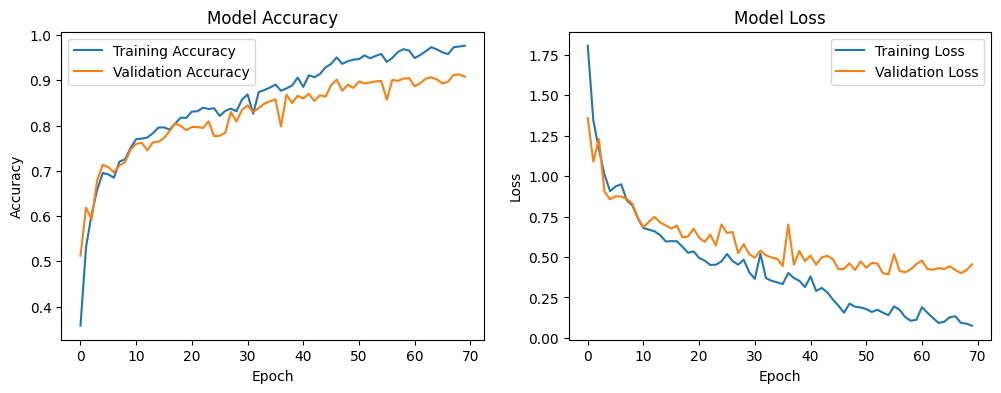

In [27]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load UrbanSound8K metadata
# Note: In Kaggle, dataset should be added to the notebook
DATASET_PATH = '/kaggle/input/urbansound8k'
metadata = pd.read_csv(os.path.join(DATASET_PATH, 'UrbanSound8K.csv'))

# 2. Function to extract MFCC features from audio files
def extract_features(file_path, n_mfcc=40, max_len=174):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=22050)
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        # Pad or truncate to fixed length
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        return mfcc.T  # Shape: (max_len, n_mfcc)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# 3. Prepare dataset
def prepare_dataset(metadata, dataset_path, n_mfcc=40, max_len=174):
    X = []
    y = []
    for idx, row in metadata.iterrows():
        file_path = os.path.join(dataset_path, f'fold{row["fold"]}', row['slice_file_name'])
        features = extract_features(file_path, n_mfcc, max_len)
        if features is not None:
            X.append(features)
            y.append(row['class'])
    return np.array(X), np.array(y)

# Extract features and labels
X, y = prepare_dataset(metadata, DATASET_PATH)

# Encode labels
le = LabelEncoder()
y_encoded = to_categorical(le.fit_transform(y))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Build LSTM model
def build_lstm_model(input_shape, num_classes):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model parameters
input_shape = (X_train.shape[1], X_train.shape[2])  # (max_len, n_mfcc)
num_classes = y_encoded.shape[1]  # 10 classes

# Initialize and compile model
model = build_lstm_model(input_shape, num_classes)

# 5. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=70,
    batch_size=32,
    verbose=1
)

# 6. Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# 7. Save the model and label encoder
model.save('urbansound8k_lstm_model.h5')
np.save('label_encoder_classes.npy', le.classes_)

# Optional: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('training_history.png')